# 3.6 Mini-analiză integrată pe dataset-ul Titanic

Această secțiune explorează factorii care au influențat supraviețuirea pasagerilor de pe Titanic în 1912. Vom analiza relația dintre rata de supraviețuire, clasa biletului și sexul pasagerilor folosind bibliotecile **Pandas**, **Seaborn** și **Matplotlib**.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Setare temă vizuală
sns.set_theme(style='whitegrid', palette='muted')

# Încărcarea dataset-ului
titanic = sns.load_dataset('titanic')

print("=== Informații generale ===")
print(f"Dimensiune: {titanic.shape}")
print(f"\nValori lipsă:\n{titanic.isnull().sum()[titanic.isnull().sum() > 0]}")
print(f"\nRata globală de supraviețuire: {titanic['survived'].mean():.1%}")

=== Informații generale ===
Dimensiune: (891, 15)

Valori lipsă:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Rata globală de supraviețuire: 38.4%


### Statistici descriptive

Calculăm ratele de supraviețuire grupate după sex și clasă pentru a identifica tendințele inițiale din date.

In [2]:
# --- Rata de supraviețuire per sex ---
print("\n=== Rata de supraviețuire per sex ===")
rata_sex = titanic.groupby('sex', observed=True)['survived'].mean().round(3)
print(rata_sex)

# --- Rata de supraviețuire per clasă ---
print("\n=== Rata de supraviețuire per clasă ===")
rata_clasa = titanic.groupby('class', observed=True)['survived'].mean().round(3)
print(rata_clasa)

# --- Tabel încrucișat: supraviețuire per sex și clasă ---
print("\n=== Rata de supraviețuire per sex și clasă ===")
pivot = titanic.pivot_table(values='survived',
                            index='class',
                            columns='sex',
                            aggfunc='mean',
                            observed=True).round(3)
display(pivot)


=== Rata de supraviețuire per sex ===
sex
female    0.742
male      0.189
Name: survived, dtype: float64

=== Rata de supraviețuire per clasă ===
class
First     0.630
Second    0.473
Third     0.242
Name: survived, dtype: float64

=== Rata de supraviețuire per sex și clasă ===


sex,female,male
class,,
First,0.968,0.369
Second,0.921,0.157
Third,0.500,0.135


### Vizualizarea Datelor

Generăm grafice de tip bară pentru a evidenția diferențele de supraviețuire între sexe și clasele sociale.

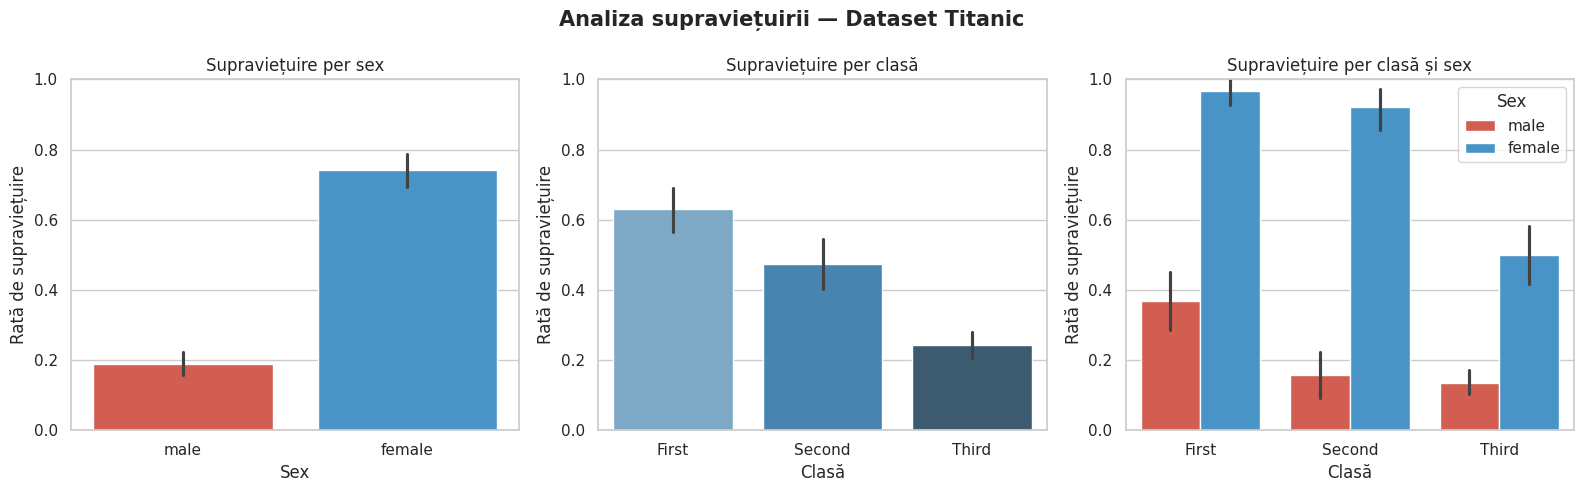

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analiza supraviețuirii — Dataset Titanic', fontsize=15, fontweight='bold')

# Subplot 1: Rata de supraviețuire per sex
sns.barplot(data=titanic, x='sex', y='survived', hue='sex', ax=axes[0],
            errorbar='ci', palette=['#e74c3c', '#3498db'], legend=False)
axes[0].set_title('Supraviețuire per sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Rată de supraviețuire')
axes[0].set_ylim(0, 1)

# Subplot 2: Rata de supraviețuire per clasă
sns.barplot(data=titanic, x='class', y='survived', hue='class', ax=axes[1],
            errorbar='ci', order=['First', 'Second', 'Third'],
            palette='Blues_d', legend=False)
axes[1].set_title('Supraviețuire per clasă')
axes[1].set_xlabel('Clasă')
axes[1].set_ylabel('Rată de supraviețuire')
axes[1].set_ylim(0, 1)

# Subplot 3: Rata per sex și clasă
sns.barplot(data=titanic, x='class', y='survived', hue='sex',
            ax=axes[2], errorbar='ci',
            order=['First', 'Second', 'Third'],
            palette=['#e74c3c', '#3498db'])
axes[2].set_title('Supraviețuire per clasă și sex')
axes[2].set_xlabel('Clasă')
axes[2].set_ylabel('Rată de supraviețuire')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Sex')

plt.tight_layout()
plt.savefig('titanic_analiza.png', dpi=150, bbox_inches='tight')
plt.show()

### Concluzii

În urma analizei, se observă că femeile au avut o rată de supraviețuire considerabil mai mare decât bărbații în toate categoriile, confirmând protocolul prioritizării acestora în caz de urgență. De asemenea, pasagerii din prima clasă au avut șanse mult mai mari de salvare comparativ cu cei din clasele inferioare, indicând o influență clară a statutului social. Discrepanța cea mai mare este vizibilă în cazul bărbaților din clasa a treia, care au înregistrat cea mai mică rată de supraviețuire. Aceste date reflectă atât normele sociale ale epocii, cât și barierele logistice întâmpinate de pasagerii de la nivelurile inferioare ale navei.